# 05 — Results Comparison & Final Visualization
Load all results, create paper-ready tables and plots.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt, seaborn as sns
from src import config
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load All Saved Results

In [2]:
metrics_dir = '../results/metrics'
all_results = {}

for f in os.listdir(metrics_dir):
    if f.endswith('.json'):
        with open(os.path.join(metrics_dir, f)) as fp:
            data = json.load(fp)
            all_results.update(data)
            print(f"Loaded {f}: {list(data.keys())}")

print(f"\nTotal models loaded: {len(all_results)}")

Loaded METR-LA_baselines_results.json: ['ARIMA', 'RandomForest', 'LSTM']
Loaded PEMS-BAY_gnn_results.json: ['STGCN', 'DCRNN']
Loaded PEMS-BAY_baselines_results.json: ['ARIMA', 'RandomForest', 'LSTM']

Total models loaded: 5


## 2. Paper-Ready Results Table

In [3]:
rows = []
for model, r in all_results.items():
    for h in ['15min', '30min', '60min']:
        if h in r:
            rows.append({'Model': model, 'Horizon': h,
                         'MAE': round(r[h]['MAE'], 4),
                         'RMSE': round(r[h]['RMSE'], 4),
                         'MAPE (%)': round(r[h]['MAPE'], 2)})

df = pd.DataFrame(rows)
pivot_mae = df.pivot_table(index='Model', columns='Horizon', values='MAE', sort=False)
pivot_rmse = df.pivot_table(index='Model', columns='Horizon', values='RMSE', sort=False)
pivot_mape = df.pivot_table(index='Model', columns='Horizon', values='MAPE (%)', sort=False)

print("=== MAE by Model and Horizon ===")
print(pivot_mae[['15min','30min','60min']].to_string(float_format='%.4f'))
print("\n=== RMSE ===")
print(pivot_rmse[['15min','30min','60min']].to_string(float_format='%.4f'))
print("\n=== MAPE (%) ===")
print(pivot_mape[['15min','30min','60min']].to_string(float_format='%.2f'))

# Save CSV for paper
df.to_csv('../results/metrics/paper_results_table.csv', index=False)
print("\nSaved to results/metrics/paper_results_table.csv")

=== MAE by Model and Horizon ===
Horizon       15min  30min  60min
Model                            
ARIMA        1.7342 2.2722 3.0955
RandomForest 1.5466 2.1344 2.9137
LSTM         2.5200 2.5534 2.6835
STGCN        2.0757 2.3001 2.5920
DCRNN        1.4818 1.9462 2.4917

=== RMSE ===
Horizon       15min  30min  60min
Model                            
ARIMA        3.9618 5.2491 7.0620
RandomForest 3.2392 4.6334 6.1077
LSTM         4.8072 4.8796 5.1230
STGCN        3.6364 4.2183 4.9013
DCRNN        2.9561 4.0513 5.1366

=== MAPE (%) ===
Horizon       15min  30min  60min
Model                            
ARIMA          3.63   4.94   7.03
RandomForest   3.33   5.02   7.32
LSTM           5.86   5.90   6.17
STGCN          4.45   5.13   6.04
DCRNN          3.18   4.45   5.96

Saved to results/metrics/paper_results_table.csv


## 3. Model Comparison Bar Charts

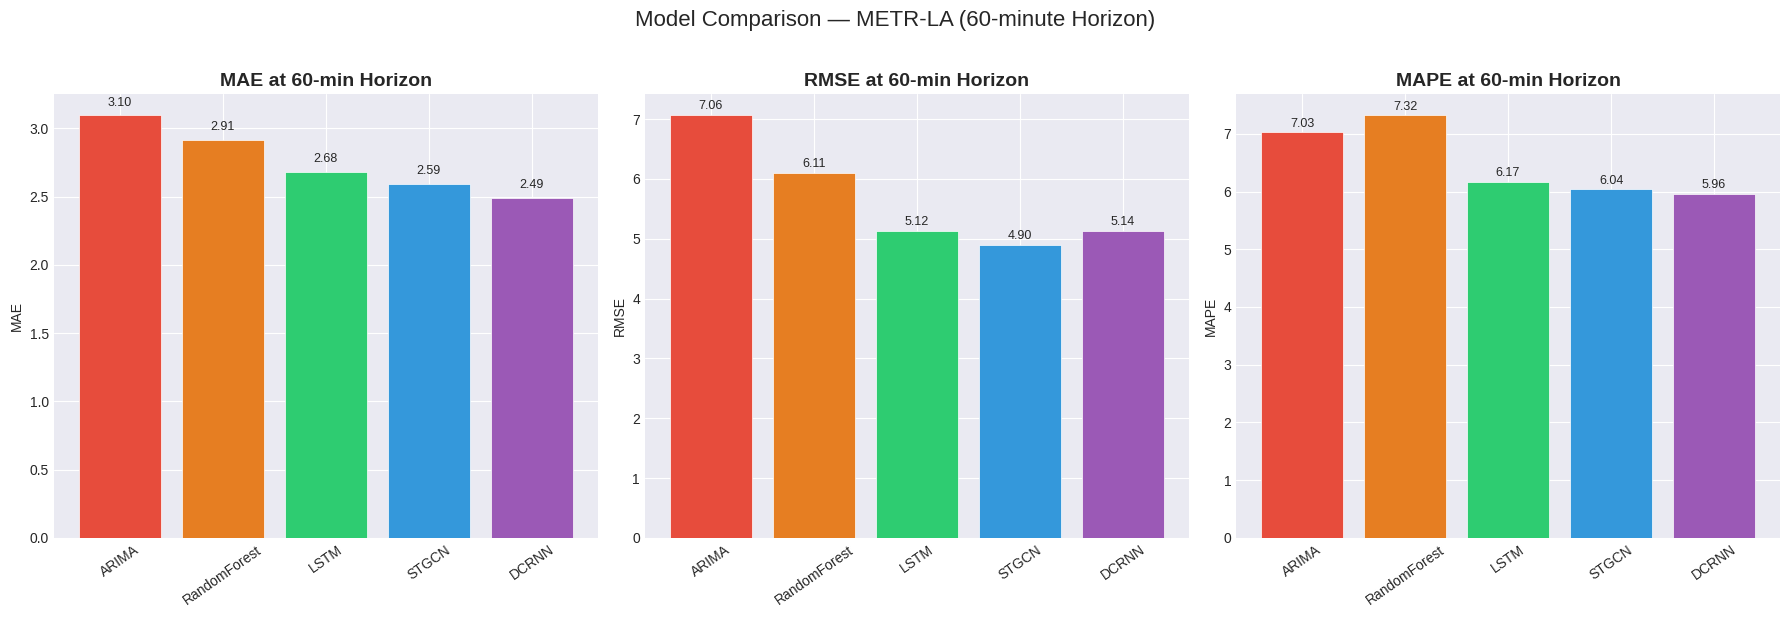

In [4]:
models = list(all_results.keys())
colors = {'ARIMA':'#e74c3c','RandomForest':'#e67e22','HistAvg':'#95a5a6',
          'LastValue':'#bdc3c7','LSTM':'#2ecc71','STGCN':'#3498db','DCRNN':'#9b59b6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    vals = [all_results[m]['60min'][metric] for m in models if '60min' in all_results[m]]
    names = [m for m in models if '60min' in all_results[m]]
    cols = [colors.get(n, '#7f8c8d') for n in names]
    bars = axes[idx].bar(names, vals, color=cols, edgecolor='white', linewidth=0.5)
    axes[idx].set_title(f'{metric} at 60-min Horizon', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=35)
    for b, v in zip(bars, vals):
        axes[idx].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{v:.2f}',
                      ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — METR-LA (60-minute Horizon)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../results/plots/final_comparison_60min.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Horizon Performance — Error Growth

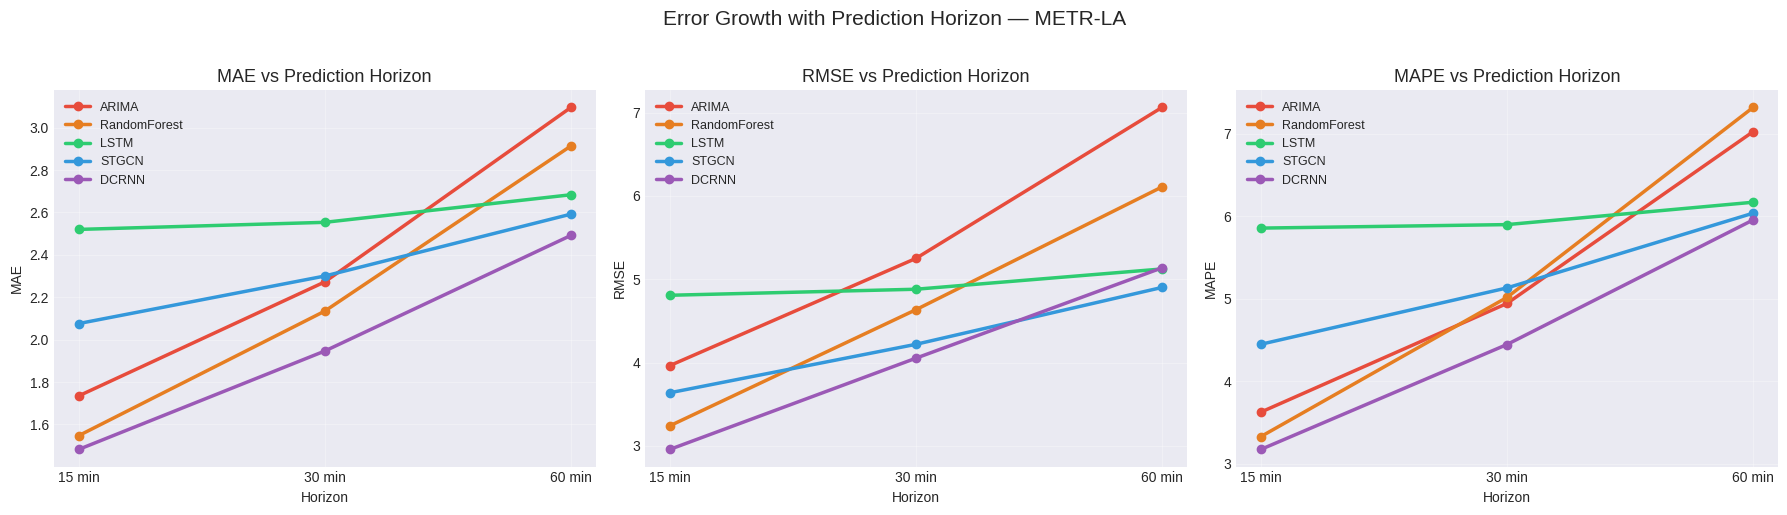

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
horizons = ['15min', '30min', '60min']
h_labels = ['15 min', '30 min', '60 min']

for idx, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    for model in models:
        if all(h in all_results[model] for h in horizons):
            vals = [all_results[model][h][metric] for h in horizons]
            c = colors.get(model, '#7f8c8d')
            axes[idx].plot(h_labels, vals, marker='o', linewidth=2.5, label=model, color=c)
    axes[idx].set_title(f'{metric} vs Prediction Horizon', fontsize=13)
    axes[idx].set_xlabel('Horizon')
    axes[idx].set_ylabel(metric)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Error Growth with Prediction Horizon — METR-LA', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/plots/final_horizon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. GNN Improvement Analysis

In [6]:
print("=== GNN vs Non-Graph Models ===\n")
non_graph = ['ARIMA', 'RandomForest', 'LSTM', 'HistAvg', 'LastValue']
graph_models = ['STGCN', 'DCRNN']

for gnn in graph_models:
    if gnn not in all_results:
        continue
    gnn_mae = all_results[gnn]['overall']['MAE']
    print(f"{gnn} (MAE={gnn_mae:.4f}):")
    for ng in non_graph:
        if ng in all_results and 'overall' in all_results[ng]:
            ng_mae = all_results[ng]['overall']['MAE']
            imp = (ng_mae - gnn_mae) / ng_mae * 100
            symbol = '↑' if imp > 0 else '↓'
            print(f"  vs {ng:<15} {symbol} {abs(imp):.1f}% {'better' if imp > 0 else 'worse'}")
    print()

=== GNN vs Non-Graph Models ===

STGCN (MAE=2.2937):
  vs ARIMA           ↓ 0.8% worse
  vs RandomForest    ↓ 8.6% worse
  vs LSTM            ↑ 10.9% better

DCRNN (MAE=1.9023):
  vs ARIMA           ↑ 16.4% better
  vs RandomForest    ↑ 9.9% better
  vs LSTM            ↑ 26.1% better



## 6. Radar Chart — Multi-Metric Comparison

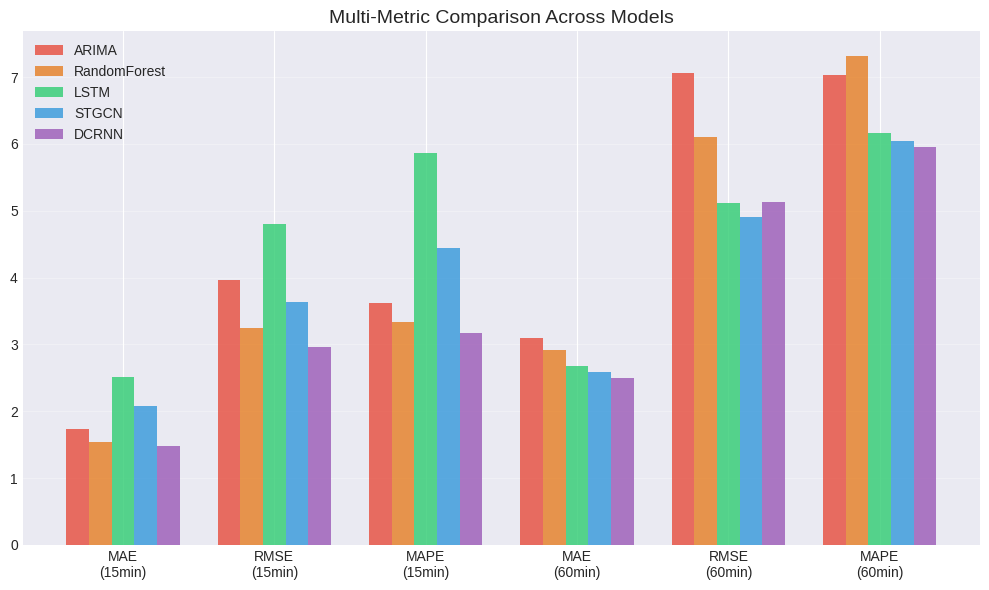

In [7]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 6))
metric_names = ['MAE\n(15min)', 'RMSE\n(15min)', 'MAPE\n(15min)',
                'MAE\n(60min)', 'RMSE\n(60min)', 'MAPE\n(60min)']

x = np.arange(len(metric_names))
width = 0.15
offset = 0

for model in ['ARIMA', 'RandomForest', 'LSTM', 'STGCN', 'DCRNN']:
    if model not in all_results:
        continue
    r = all_results[model]
    vals = [r.get('15min',{}).get('MAE',0), r.get('15min',{}).get('RMSE',0),
            r.get('15min',{}).get('MAPE',0), r.get('60min',{}).get('MAE',0),
            r.get('60min',{}).get('RMSE',0), r.get('60min',{}).get('MAPE',0)]
    c = colors.get(model, '#7f8c8d')
    ax.bar(x + offset, vals, width, label=model, color=c, alpha=0.8)
    offset += width

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metric_names)
ax.set_title('Multi-Metric Comparison Across Models', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/plots/multi_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary for Paper

Copy these key numbers into your paper:

- Best model overall: *check MAE column*
- GNN improvement over LSTM: *check Section 5 output*
- Error growth: *15min MAE is X, 60min MAE is Y → Z% increase*
- Graph structure contribution: *STGCN/DCRNN vs LSTM*

In [8]:
print("\n" + "="*60)
print("  FINAL RANKING — METR-LA")
print("="*60)
ranked = sorted(all_results.items(), key=lambda x: x[1].get('overall',{}).get('MAE', 999))
for i, (name, r) in enumerate(ranked):
    if 'overall' in r:
        mae = r['overall']['MAE']
        rmse = r['overall']['RMSE']
        mape = r['overall']['MAPE']
        badge = "🥇" if i==0 else ("🥈" if i==1 else ("🥉" if i==2 else "  "))
        print(f"  {badge} {name:<20} MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%")
print("="*60)


  FINAL RANKING — METR-LA
  🥇 DCRNN                MAE=1.9023  RMSE=4.0310  MAPE=4.36%
  🥈 RandomForest         MAE=2.1112  RMSE=4.6690  MAPE=5.00%
  🥉 ARIMA                MAE=2.2760  RMSE=5.4049  MAPE=4.98%
     STGCN                MAE=2.2937  RMSE=4.2226  MAPE=5.13%
     LSTM                 MAE=2.5749  RMSE=4.9187  MAPE=5.95%
